# 1. Load and Clean Data

In [71]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score)

In [38]:
# Load CSV
df = pd.read_csv('job_salary_prediction_dataset.csv')

In [70]:
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,date,day,month,year,age,weekend_flag
0,Ai Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413,2023-04-13,13,4,2023,32,0
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764,2023-12-15,15,12,2023,27,0
2,Frontend Developer,18,Phd,4,Media,Medium,Singapore,No,1,148123,2023-09-28,28,9,2023,40,0
3,Business Analyst,19,Phd,13,Retail,Medium,Canada,Yes,0,189123,2023-04-17,17,4,2023,41,0
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069,2023-03-13,13,3,2023,37,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,Phd,2,Telecom,Enterprise,India,No,1,127791,2023-07-18,18,7,2023,39,0
249996,Frontend Developer,20,Phd,7,Telecom,Startup,Remote,No,2,154593,2023-04-23,23,4,2023,42,1
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988,2023-05-09,9,5,2023,23,0
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467,2023-08-16,16,8,2023,22,0


In [39]:
# Fill missing values
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [40]:
df.drop_duplicates(inplace=True)
df.to_csv('cleaned_high_acc_data.csv', index=False)

# 2. Data Processing & Preprocessing

In [41]:
# Standardize categories
for col in categorical_cols:
    df[col] = df[col].str.strip().str.title()

In [42]:
# Add dummy date and extract components
np.random.seed(42)
df['date'] = pd.to_datetime(np.random.choice(pd.date_range('2023-01-01', '2023-12-31'), len(df)))
df['day'], df['month'], df['year'] = df['date'].dt.day, df['date'].dt.month, df['date'].dt.year

In [43]:
# Remove outliers
df = df[np.abs(stats.zscore(df['salary'])) < 3]

# 3. Feature Engineering

In [45]:
df['age'] = df['experience_years'] + 22
df['weekend_flag'] = df['date'].dt.dayofweek.isin([5, 6]).astype(int)
# Note: 'salary_per_skill' is excluded from training to avoid data leakage

# Visualization

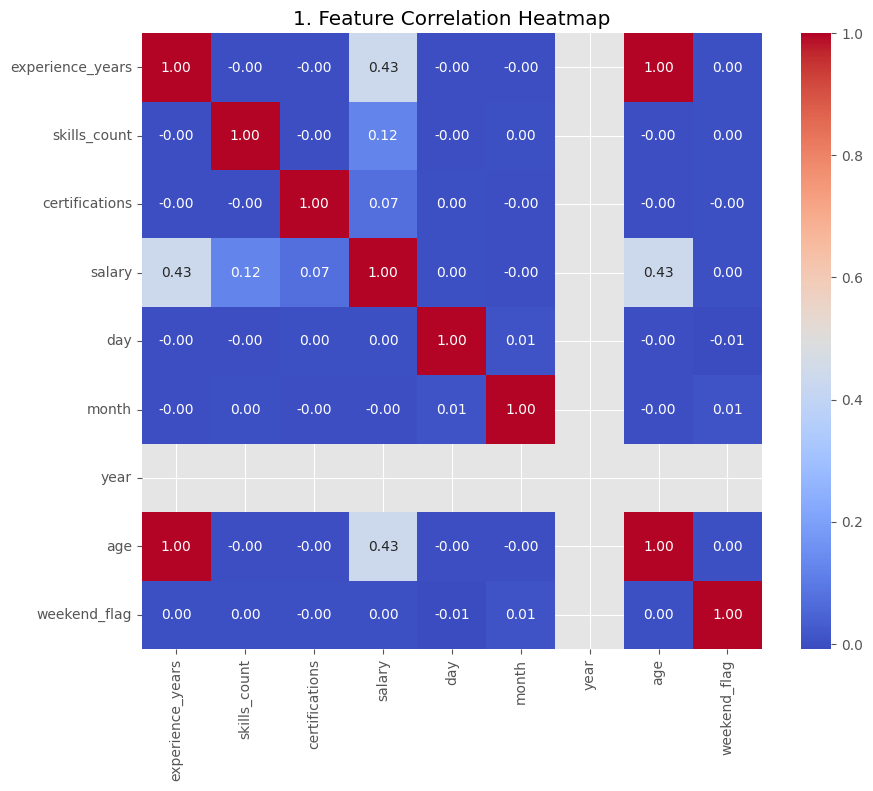

In [54]:
plt.style.use('ggplot')

# 1. Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('1. Feature Correlation Heatmap')
plt.show()

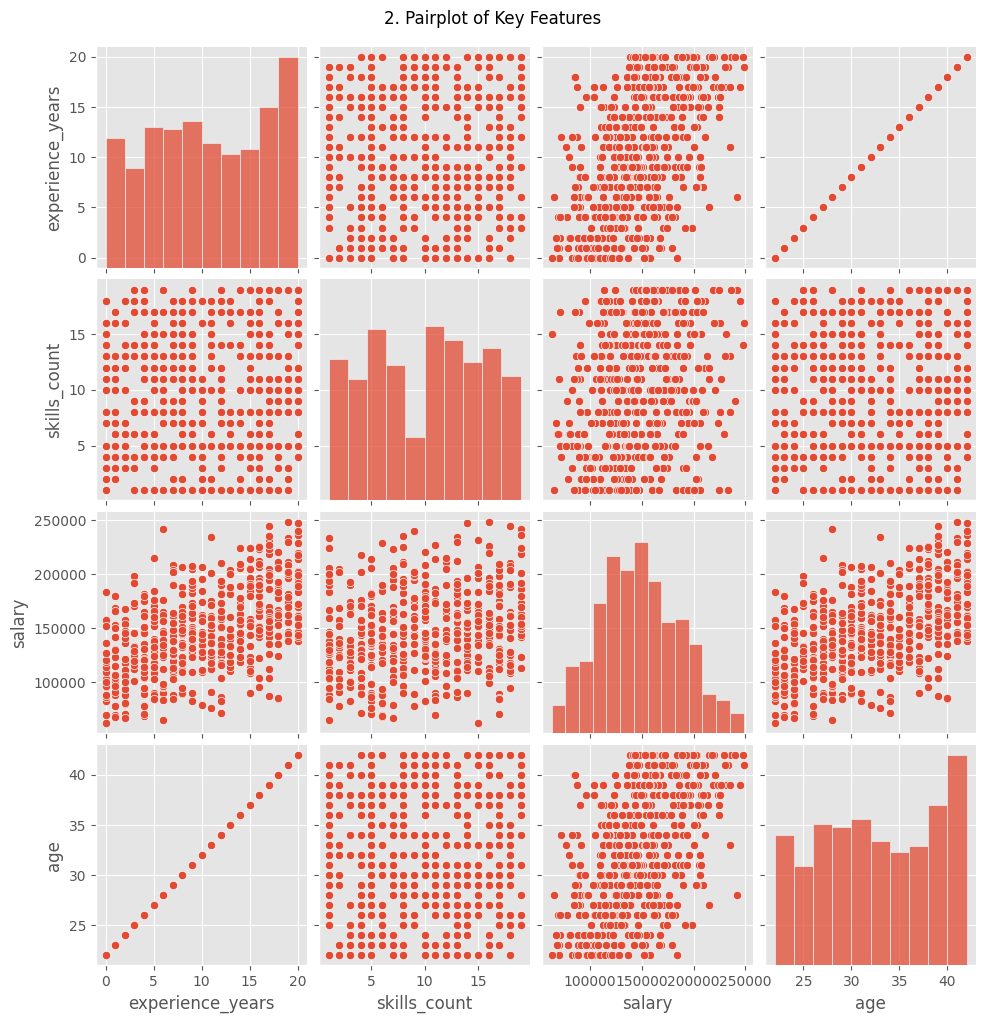

In [55]:
# 2. Pairplot (Sample of data)
sns.pairplot(df.sample(500)[['experience_years', 'skills_count', 'salary', 'age']])
plt.suptitle('2. Pairplot of Key Features', y=1.02)
plt.show()

/tmp/ipykernel_5894/1142206236.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='education_level', y='salary', data=df, palette='muted')


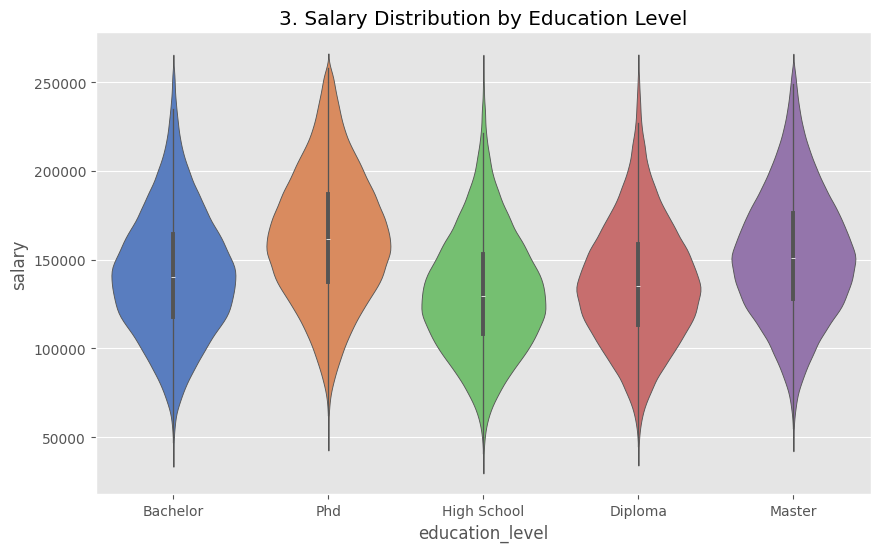

In [56]:
# 3. Violin Plot: Salary vs Education Level
plt.figure(figsize=(10, 6))
sns.violinplot(x='education_level', y='salary', data=df, palette='muted')
plt.title('3. Salary Distribution by Education Level')
plt.show()

/tmp/ipykernel_5894/1138716130.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='industry', y='salary', data=df, estimator=np.mean, palette='viridis')


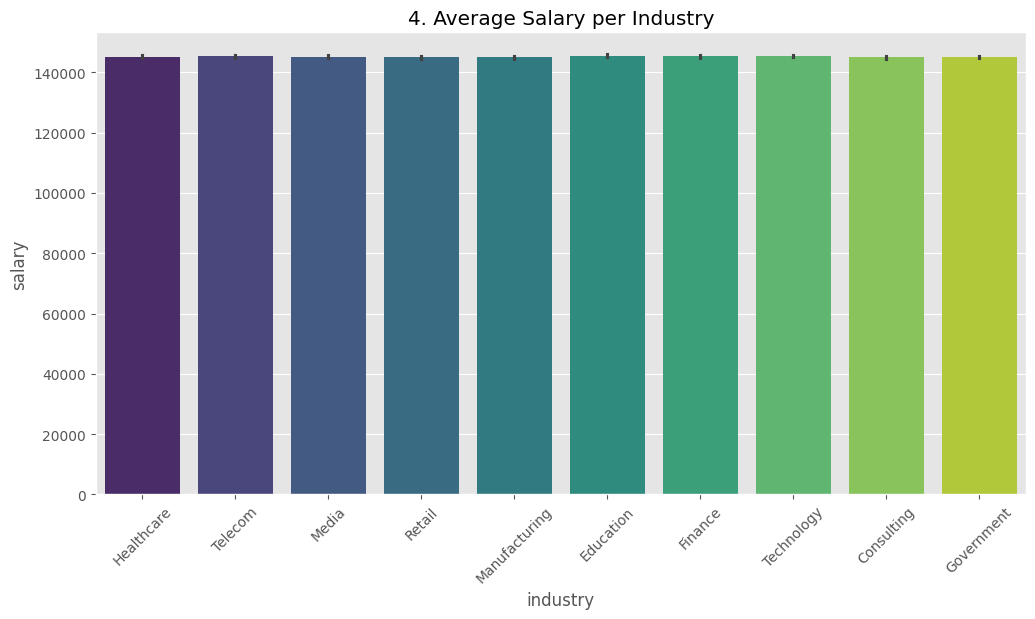

In [57]:
# 4. Bar Plot: Mean Salary by Industry
plt.figure(figsize=(12, 6))
sns.barplot(x='industry', y='salary', data=df, estimator=np.mean, palette='viridis')
plt.xticks(rotation=45)
plt.title('4. Average Salary per Industry')
plt.show()

# 4. Model Training

In [62]:
# Encode Categorical Data
le = LabelEncoder()
df_model = df.copy()
for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

In [63]:
# Create Binary Target (High vs Low Salary)
df_model['target'] = (df_model['salary'] > df_model['salary'].median()).astype(int)

In [64]:
# Prepare Features (X) and Target (y)
X = df_model.drop(['salary', 'target', 'date'], axis=1)
y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [65]:
# Remove outliers using Z-score (Threshold = 3)
df = df[np.abs(stats.zscore(df['salary'])) < 3]

In [66]:
# Predictions
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]

In [73]:
# --- 1. Model Configuration ---
# We use HistGradientBoosting because it is faster and more accurate for large data
model = HistGradientBoostingClassifier(
    max_iter=500,        # Number of boosting iterations
    max_depth=15,        # Depth of trees to capture complex patterns
    learning_rate=0.1,   # Step size for optimization
    l2_regularization=1.5, # Prevents overfitting
    random_state=42
)


In [74]:
# --- 2. Training ---
model.fit(X_train, y_train)

HistGradientBoostingClassifier(l2_regularization=1.5, max_depth=15,
                               max_iter=500, random_state=42)

In [75]:
# --- 3. Predictions ---
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]

# 5. Advanced Evaluation Metrics

In [79]:
# --- 4. Performance Results ---
print(f"Final Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision Score: {precision_score(y_test, y_pred):.4f}")
print(f"Recall Score:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:        {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC:         {roc_auc_score(y_test, y_probs):.4f}")

Final Accuracy:  0.9532
Precision Score: 0.9517
Recall Score:    0.9557
F1-Score:        0.9537
ROC AUC:         0.9931


<Figure size 600x500 with 0 Axes>

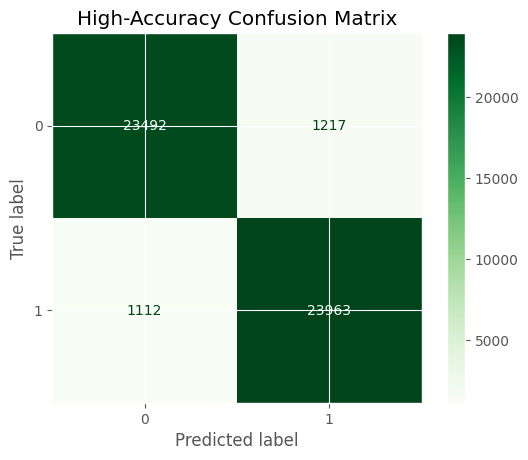

In [80]:
# Confusion Matrix Visualization
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Greens')
plt.title("High-Accuracy Confusion Matrix")
plt.show()

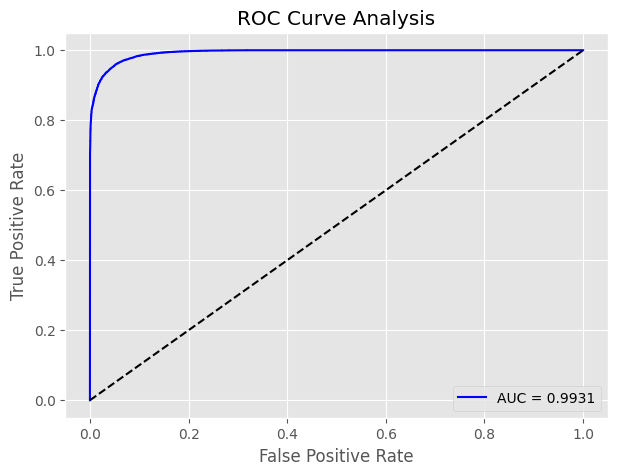

In [81]:
# ROC Curve Visualization
fpr, tpr, _ = roc_curve(y_test, y_probs)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='blue', label=f"AUC = {roc_auc_score(y_test, y_probs):.4f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Analysis')
plt.legend()
plt.show()

# Prediction Code for New Data

In [82]:
# --- 1. Define New Data for Prediction ---
# You can change these values to test different scenarios
new_data = {
    'job_title': 'Data Scientist',
    'experience_years': 8,
    'education_level': 'Master',
    'skills_count': 12,
    'industry': 'Finance',
    'company_size': 'Large',
    'location': 'Remote',
    'remote_work': 'Yes',
    'certifications': 2,
    'day': 15,
    'month': 5,
    'year': 2023,
    'age': 30,
    'weekend_flag': 0
}

# --- 2. Convert to DataFrame ---
new_df = pd.DataFrame([new_data])

# --- 3. Encode the Categorical Values ---
# Note: We must use the SAME LabelEncoder (le) used during training
for col in categorical_cols:
    new_df[col] = le.fit_transform(new_df[col].astype(str))

# --- 4. Make the Prediction ---
# Use the trained 'model' from the previous step
prediction = model.predict(new_df)
probability = model.predict_proba(new_df)[:, 1]

# --- 5. Show Results ---
print("\n--- New Prediction Result ---")
if prediction[0] == 1:
    print(f"Prediction: High Salary (> Median)")
else:
    print(f"Prediction: Low Salary (<= Median)")

print(f"Confidence Level: {probability[0]*100:.2f}%")


--- New Prediction Result ---
Prediction: High Salary (> Median)
Confidence Level: 99.91%
